In [ ]:
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
import numpy as np
import pickle

## Helper functions

In [2]:
def save_obj_to_gwyddion(dataobj,filename,gwytypes=['image']):
    """save_obj_to_gwyddion(): writes qudi data object to Gwyddion file
        input:  
        - dataobj: proteusQ data object of from dataobj['data_key']
        - filename: file path to save object
        - prefix:  name to be prefixed to all head objects

        requirements:
        dataobj['scan_type'] must contain keys {coord0[], coord1[], data[,], params[coord0-1_start-stop], si_units, nice_name}
    """

    # check for existance of valid object names
    datakeys = list(dataobj.keys())

    # overall object container
    objout = gwy.objects.GwyContainer()

    for dataki,datak in enumerate(sorted(datakeys, key=str.lower)):
        meas = dataobj[datak]

        # check that data is valid
        if not {'coord0_arr','coord1_arr','data'}.issubset(set(meas.keys())):
            continue 

        # check that there is non-trivial data (skip empty measurements)
        if np.sum(meas['data']) == 0.0:
            continue

        # transform data
        #scalefactor = meas['scale_fac']
        coord0 = meas['coord0_arr']
        coord1 = meas['coord1_arr']
        data_si = meas['data'] #* scalefactor

        params = meas['params']
        coord0_start = next(k for k in params.keys() if k.startswith('coord0_start'))
        coord0_stop = next(k for k in params.keys() if k.startswith('coord0_stop'))
        coord1_start = next(k for k in params.keys() if k.startswith('coord1_start'))
        coord1_stop = next(k for k in params.keys() if k.startswith('coord1_stop'))

        xy_units = meas['xy_units']
        z_units = meas['si_units']
        measname = datak + ":" + meas['nice_name']

        # encode to image
        img = gwy.objects.GwyDataField(data=data_si, si_unit_xy=xy_units, si_unit_z=z_units)
        img.xoff = params[coord0_start]
        img.xreal = params[coord0_stop] - params[coord0_start]
        img.yoff = params[coord1_start]
        img.yreal = params[coord1_stop] - params[coord1_start]

        # add to parent object 
        if 'image' in gwytypes: 
            # image types
            basekey = '/' + str(dataki) + '/data'
            objout[basekey + '/title'] = measname
            objout['/' + str(dataki) + '/base/palette'] = 'Sky'
            objout[basekey] = img
            # comment meta data
            if meas['params']:
                d = {key: str(val) for key, val in meas['params'].items()}
                meta = gwy.objects.GwyContainer(d)
                objout['/' + str(dataki) + '/meta'] = meta

    # write out file    
    if objout:
        objout.tofile(filename)

## Define file path

In [38]:
path = r'D:\Data\RT_AFM_Data\2025\09\20250922\Lock-In-Tip'+r'/'
filebeginning = '2025-09-22_05-20-38_Gradiometry_scan_A-T16-25_194.819922kHz_'
#here the beginning of the filename, including the date and sample name, is needed
filepath = path + filebeginning

## Load data from pickel

In [39]:
with open(filepath+'.pickle', 'rb') as f:
    data = pickle.load(f)

## Calculate

In [40]:
topo_arr = np.load(filepath+'_topo.npy')    
    
# for key in data.keys():
#     data[key].update({"scan_array_x":np.linspace(4, 6, 20)*1e-6,
#                           "scan_array_y": np.linspace(7, 9, 20)*1e-6})

# with open(path+'_new.pickle', 'wb') as f:
#     pickle.dump(data, f)    

from logic.pulsed.pulsed_analysis_methods.basic_analysis_methods import BasicPulseAnalyzer
Analyzer = BasicPulseAnalyzer(pulsedmeasurementlogic_AWG)
pulsedmeasurementlogic_AWG.set_fast_counter_settings({"bin_width":1e-9})

import matplotlib as mpl
from mpl_toolkits.axes_grid1 import make_axes_locatable
from uncertainties import ufloat
from uncertainties import unumpy
from uncertainties import umath
from lmfit import Model
from skimage.restoration import unwrap_phase
import cv2 as cv

def analyse_sum(data):
    sig = np.zeros((len(data)))
    err = np.zeros((len(data)))
    for i, d in enumerate(data):
        ret = Analyzer.analyse_mean(np.array([d]), 200e-9, 400e-9)
        sig[i] = ret[0]
        err[i] = ret[1]
    return unumpy.uarray(sig, err)

key = list(data.keys())[0]
t_0 = data[key]["t_0"]*1e6
data_raw = data[key]["data_raw"]
s = data_raw.shape
data_arr_nom = np.zeros((s[0], s[1]))
data_arr_err = np.zeros((s[0], s[1]))
counts_arr_nom = np.zeros((s[0], s[1]))
for idy in range(s[0]):
    for idx in range(s[1]):
        ret = analyse_sum(data_raw[idy,idx,:])
        cx = ret[0]
        cy = ret[1]
        cxa = ret[2]
        cya = ret[3]
        phase = umath.atan2((cya-cy),(cx-cxa))
        data_arr_nom[idy,idx] = unumpy.nominal_values(phase).copy()
        data_arr_err[idy,idx] = unumpy.std_devs(phase).copy()
        counts_arr_nom[idy,idx] = unumpy.nominal_values((cx+cy+cxa+cya)/4).copy()

phase = unumpy.uarray(data_arr_nom, data_arr_err)
phase_nom = unumpy.nominal_values(phase)
phase_err = unumpy.std_devs(phase)
counts = counts_arr_nom

## Plot

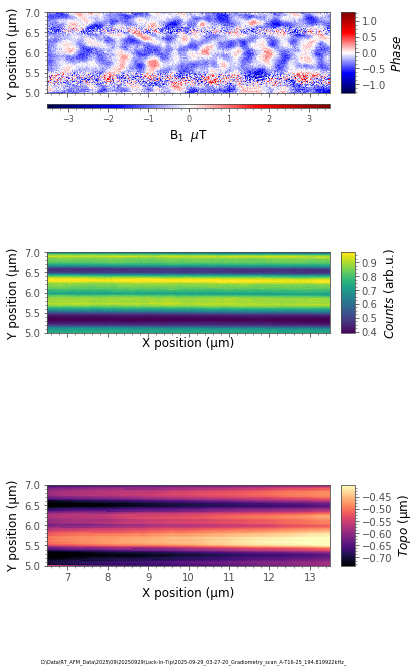

In [44]:
save = False
B1_data = True
#Plot analysed Data from PODMR
x = data[key]["scan_array_x"]*1e6
y = data[key]["scan_array_y"]*1e6

fig, axs = plt.subplots(3,1, gridspec_kw={"height_ratios": [1, 1, 1]}, sharex=True)
#plt.title("Low current - 3us tau")
plt.rcParams['figure.figsize'] = (5, 15)
plt.tight_layout()
fontsize = 12

low_centile = 0
high_centile = 100
d = phase_nom
#d = unwrap_phase(phase_nom)

ker = 0
#ker = 3
#d = cv.GaussianBlur(d,(ker,ker),0)

im = axs[0].pcolormesh(x,y,d,cmap=plt.cm.get_cmap('seismic'), vmin=np.nanpercentile(d, low_centile), 
                       vmax=np.nanpercentile(d, low_centile)*-1)

if B1_data == True:
    f_TF = data[key]["Res_freq"]
    B1 = d / (2*np.pi*28e9) / (2*np.sin(np.pi*f_TF*data[key]["tau"]/2)**2) * np.pi*f_TF
    d = B1 * 1e6
    im2 = axs[0].pcolormesh(x,y,d,cmap=plt.cm.get_cmap('seismic'), vmin=np.nanpercentile(d, low_centile), 
                            vmax=np.nanpercentile(d, low_centile)*-1)
    np.savetxt(path + '_B1.txt', d)
    grad_nice_name = "B1 field"
else:
    f_TF = data[key]["Res_freq"]
    B2 = d / (2*np.pi*28e9) / (2*np.sin(np.pi*f_TF*data[key]["tau"]/2)**2) * np.pi*f_TF * np.sin(np.pi*f_TF*data[key]["tau"])
    d = B2 * 1e6
    im2 = axs[0].pcolormesh(x,y,d,cmap=plt.cm.get_cmap('seismic'), vmin=np.nanpercentile(d, low_centile), 
                            vmax=np.nanpercentile(d, low_centile)*-1)
    grad_nice_name = "B2 field"

grad_gwy = d
axs[0].set_ylabel('Y position (\u03BCm)',fontsize = fontsize)
axs[0].set_aspect('equal')

divider = make_axes_locatable(axs[0])
cax = divider.append_axes("right", size="5%", pad=0.15)
cbar = plt.colorbar(im, cax=cax)
cbar.set_label(label='$Phase$', size=fontsize)

# Second colorbar (Optional: Different colormap)
cax2 = divider.append_axes("bottom", size="5%", pad=0.15)  # Adjust pad for spacing
cbar2 = plt.colorbar(im2, cax=cax2, orientation="horizontal")
cbar2.ax.tick_params(labelsize=fontsize/1.5)
label = 'B$_1$  $\mu$T' if B1_data else 'B$_2$  $\mu$T'
cbar2.set_label(label=label, size=fontsize)

#################### Counts plot
low_centile = 1
high_centile = 99
d = counts/counts.max()
counts_gwy = d
im = axs[1].pcolormesh(x,y,d,cmap=plt.cm.get_cmap('viridis'), vmin=np.nanpercentile(d, low_centile), 
                       vmax=np.nanpercentile(d, high_centile))

axs[1].set_xlabel('X position (\u03BCm)',fontsize = fontsize)
axs[1].set_ylabel('Y position (\u03BCm)',fontsize = fontsize)

axs[1].set_aspect('equal')

divider = make_axes_locatable(axs[1])
cax = divider.append_axes("right", size="5%", pad=0.15)
cbar = fig.colorbar(im, cax=cax)
cbar.set_label(label='$Counts$ (arb.u.)', size=fontsize)

#################### Topo plot
low_centile = 1
high_centile = 99
tilt_correct = True

d = (topo_arr - np.max(topo_arr)) *-1e6
if tilt_correct == True:
    fit_para_x = np.polyfit(x, d[0,:], 1)
    fit_para_y = np.polyfit(y[3:], d[3:,0], 1)
    d_correct = d.copy()
    d_correct = d_correct-fit_para_x[0]*x#-fit_para_x[1]
    d_correct = d_correct.transpose()-fit_para_y[0]*y#-fit_para_y[1]
    d = d_correct.transpose()

topo_gwy = d
im = axs[2].pcolormesh(x,y,d,cmap=plt.cm.get_cmap('magma'), vmin=np.nanpercentile(d, low_centile), 
                       vmax=np.nanpercentile(d, high_centile))

axs[2].set_xlabel('X position (\u03BCm)',fontsize = fontsize)
axs[2].set_ylabel('Y position (\u03BCm)',fontsize = fontsize)

axs[2].set_aspect('equal')

divider = make_axes_locatable(axs[2])
cax = divider.append_axes("right", size="5%", pad=0.15)
cbar = fig.colorbar(im, cax=cax)
cbar.set_label(label='$Topo$ (µm)', size=fontsize)

fig.suptitle(f'{path}', fontsize=5, y=0.0)
path_label = '_B1.png' if B1_data else '_B2.png'
if ker!=0:
    path_label = '_filt'+path_label
if save==True:
    plt.savefig(path+path_label, dpi=900, bbox_inches="tight")
plt.show()

## Plot complete data set

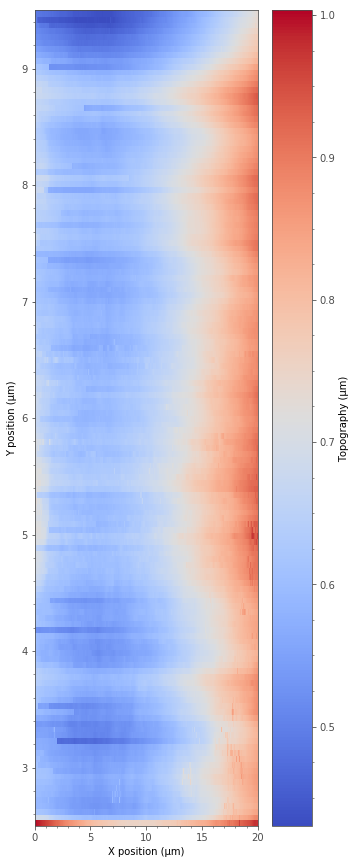

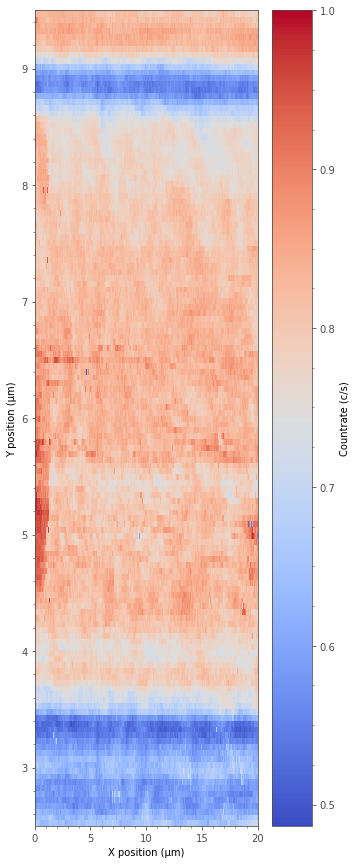

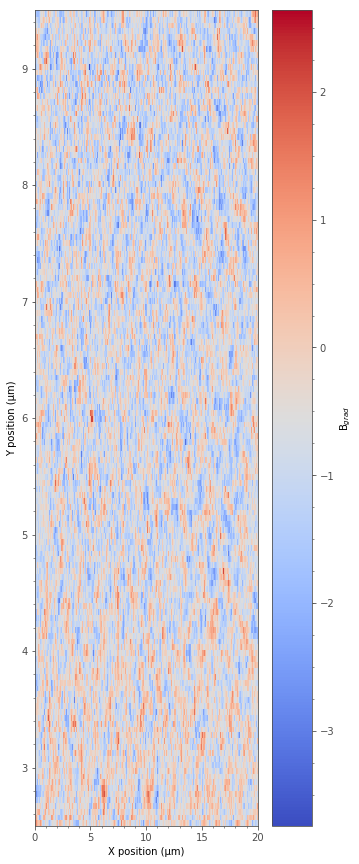

In [42]:
#Plot analysed Data from PODMR
x_gwy = data[key]["scan_array_x"]
y_gwy = data[key]["scan_array_y"]
x = x_gwy*10**6
y = y_gwy*10**6

#for gwyddion
dataobj = {}

## TOPO ##

low_centile = 0
high_centile = 100
d = topo_gwy
plt.pcolormesh(x,y,d,cmap=plt.cm.get_cmap('coolwarm'), vmin =np.nanpercentile(d, low_centile), vmax = np.nanpercentile(d, high_centile))
plt.xlabel('X position (\u03BCm)')
plt.ylabel('Y position (\u03BCm)')
plt.colorbar(label = 'Topography (\u03BCm)')
plt.show()
#for gwyddion
dataobj['Topography'] = {
                            'coord0_arr':x_gwy,
                            'coord1_arr':y_gwy,
                            'data':d*1e-6,
                            'params': {'coord0_start': x_gwy[0],'coord0_stop': x_gwy[-1],'coord1_start': y_gwy[0],'coord1_stop': y_gwy[-1]},
                            'xy_units': 'm',                                                
                            'si_units': 'm',
                            'nice_name': 'Topography'
    
                        }
## COUNTS ##

low_centile = 0
high_centile = 100
d = counts_gwy
plt.pcolormesh(x,y,d,cmap=plt.cm.get_cmap('coolwarm'), vmin =np.nanpercentile(d, low_centile), vmax = np.nanpercentile(d, high_centile))
plt.xlabel('X position (\u03BCm)')
plt.ylabel('Y position (\u03BCm)')
plt.colorbar(label = 'Countrate (c/s)')
plt.show()
#for gwyddion
dataobj['Fluorescence'] = {
                            'coord0_arr':x_gwy,
                            'coord1_arr':y_gwy,
                            'data': d,
                            'params': {'coord0_start': x_gwy[0],'coord0_stop': x_gwy[-1],'coord1_start': y_gwy[0],'coord1_stop': y_gwy[-1]},
                            'xy_units': 'm',                                                
                            'si_units': 'c/s',
                            'nice_name': 'Fluorescence'
    
                        }
## RES FREQ ##

# low_centile = 0.75
# high_centile = 99.8
# data = res_freq/10**9
# plt.pcolormesh(x,y,data,cmap=plt.cm.get_cmap('coolwarm'), vmin =np.nanpercentile(data, low_centile), vmax = np.nanpercentile(data, high_centile))
# plt.xlabel('X position (\u03BCm)')
# plt.ylabel('Y position (\u03BCm)')
# plt.colorbar(label = 'Frequency (GHz)')
# plt.show()


## BFIELD CORR mT ##

low_centile = 0
high_centile = 100
d = grad_gwy # b_field_bias is found earlier from OOC fit. In tesla
plt.pcolormesh(x,y,d,cmap=plt.cm.get_cmap('coolwarm'), vmin =np.nanpercentile(d, low_centile), vmax = np.nanpercentile(d, high_centile))
plt.xlabel('X position (\u03BCm)')
plt.ylabel('Y position (\u03BCm)')
plt.colorbar(label = 'B$_{grad}$')
plt.show()
#for gwyddion
dataobj['Stray Field'] = {
                            'coord0_arr':x_gwy,
                            'coord1_arr':y_gwy,
                            'data':d/1e6,
                            'params': {'coord0_start': x_gwy[0],'coord0_stop': x_gwy[-1],'coord1_start': y_gwy[0],'coord1_stop': y_gwy[-1]},
                            'xy_units': 'm',                        
                            'si_units': 'T',
                            'nice_name': f"{grad_nice_name}"
    
                        }


## 5.a Save to new gwyddion file - data defined in previous cell

In [43]:
"""save_obj_to_gwyddion(): writes qudi data object to Gwyddion file
        input:  
        - dataobj: proteusQ data object of from dataobj['data_key']
        - filename: file path to save object
        - prefix:  name to be prefixed to all head objects

        requirements:
        dataobj['scan_type'] must contain keys {coord0[], coord1[], data[,], params[coord0-1_start-stop], si_units, nice_name}
    """
from logic import gwyfile as gwy
save_obj_to_gwyddion(dataobj=dataobj,filename=filepath+'QAFM_jupyter_corrected.gwy')

CPMG1 is used.


100%|##################################################################################| 80/80 [83:16:08<00:00, 3747.11s/it]


## Saved images in multiple formats - matplotlib style

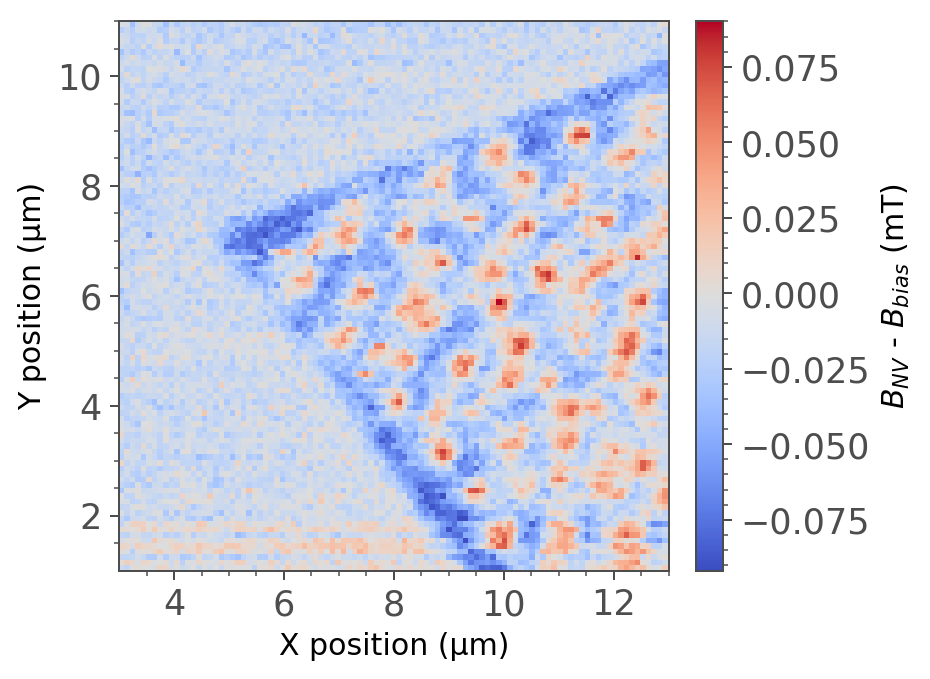

In [47]:
#Save b field image in Gauss
x = (qafm_data['Height(Dac)_fw']['coord0_arr'])*10**6
y = (qafm_data['Height(Dac)_fw']['coord1_arr'])*10**6

plt.rcParams['figure.figsize'] = (5, 4)
fontsize = 12

low_centile = 0
high_centile = 100
data = (b_field-b_field_bias)*10**3
im = plt.pcolormesh(x,y,data,cmap=plt.cm.get_cmap('coolwarm'), vmin =np.nanpercentile(data, low_centile), vmax = np.nanpercentile(data, high_centile))
plt.xlabel('X position (\u03BCm)',fontsize = fontsize)
plt.ylabel('Y position (\u03BCm)',fontsize = fontsize)

ax = plt.gca()
ax.set_aspect('equal')

divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.15)
cbar = plt.colorbar(im, cax=cax, use_gridspec=True)
cbar.set_label(label='$B_{NV}$ - $B_{bias}$ (mT)', size=fontsize)

plt.tight_layout()

with open(filepath+'QAFM_b_field_fw_fig_corrected.png', 'wb') as f:
    plt.savefig(f,format='png')
with open(filepath+'QAFM_b_field_fw_fig_corrected.pdf', 'wb') as f:
    plt.savefig(f,format='pdf')
with open(filepath+'QAFM_b_field_fw_fig_corrected.svg', 'wb') as f:
    plt.savefig(f,format='svg')

plt.show()